In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path(".") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

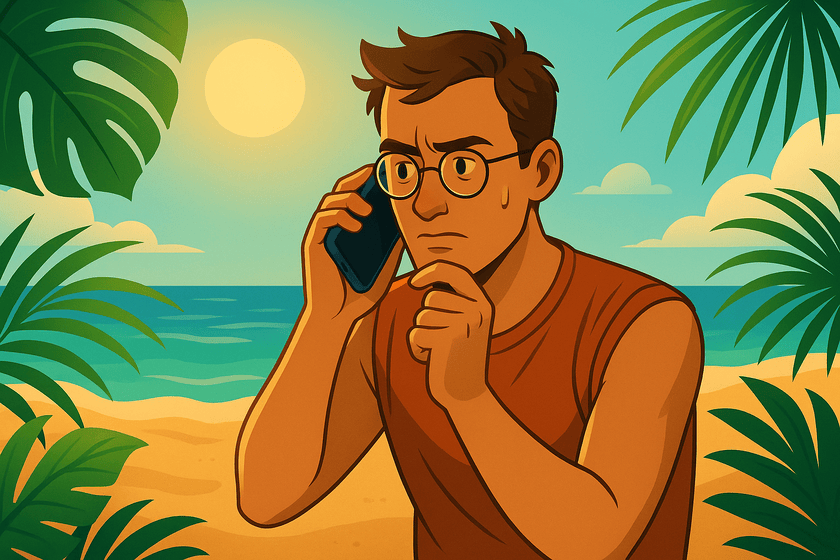

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


# --------------------------------------

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

In [37]:
data_path = '/content/drive/MyDrive/WyzwanieSolvro2026/Zadanie1/titanic.csv'

In [44]:
titanic_df = pd.read_csv(data_path)

In [45]:
titanic_df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,NaN,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [68]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Has_Cabin    891 non-null    int64  
 8   Family_Size  891 non-null    int64  
 9   Is_Alone     891 non-null    int64  
 10  Embarked_Q   891 non-null    bool   
 11  Embarked_S   891 non-null    bool   
dtypes: bool(2), float64(2), int64(8)
memory usage: 71.5 KB


##Obserwacje na podstawie widoku danych
W kontekście naszego zadania kolumny PassengerId, Name, Ticket są nieistotne - nie wnoszą żadnych informacji, które moglibyśmy wykorzystać przy predykcji tego, czy pasażer przeżył, ponieważ są unikalne dla każdego pasażera.

Wśród naszych danych znajdują się dane:

- Kategoryczne: Embarked, Sex, Pclass, Survived, Class
- Numeryczne: Age, Fare, Parch, SibSp

In [47]:
titanic_df['Has_Cabin'] = titanic_df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1) #dla osoby robiącej review: mam wątpliwość czy Has_Cabin jest potrzebna, bo większośc dnaych w kolumnie Cabin jest pusta,
                                                                                      #więc jedyne na co wpadłem, to sprawdzić czy to, że ktoś ma uzupełniony numer kabiny daje nam jakieś sensowne infromacje,
                                                                                      #ale nie mam pojęcia, czy ma to większy sens, więc jakby ktoś dał feedback byłoby superaśnie

titanic_df['Family_Size'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1             #tworzymy kolumne z wielkością rodziny

titanic_df['Is_Alone'] = (titanic_df['Family_Size'] == 1).astype(int)                 #tworzymy kolumne, z tym, czy ktoś był sam

In [48]:
titanic_df = titanic_df.drop(columns=['PassengerId', 'Ticket', 'Cabin', 'Name'])

Dropujemy kolumny, które nie będą wykorzystane (aby ograniczyć wymiarowość)

##Brakujące wartości
Sprawdzamy, które kolumny musimy uzupełnić, ze względu na brakujące w nich wartości

In [49]:
def get_missing_data(df, axis):
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc

In [50]:
get_missing_data(titanic_df, 0)

,0
Survived,0.00
Pclass,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Fare,11.00
Embarked,0.22
Has_Cabin,0.00
Family_Size,0.00


##Uzupełnianie brakujacych wartości
Brakujące wartości znajdują się w kolumnach Age, Fare i Embarked, uzupełniamy je w następujący sposób:
- Age: losowy wiek spośród wszystkich, żeby nie zaburzyć rozkładu,
- Embarked: uzupełniamy dominantą,
- Fare: uzupełniamy medianą w danych grupach (dana klasa podróży, port, z którgo wypłynęliśmy).

In [52]:
age_values = titanic_df['Age'].dropna().values
missing_age_mask = titanic_df['Age'].isna()
titanic_df.loc[missing_age_mask, 'Age'] = np.random.choice(age_values, size=missing_age_mask.sum())

titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])
titanic_df['Fare'] = titanic_df.groupby(['Pclass', 'Embarked'])['Fare'].transform(lambda x: x.fillna(x.median()))
get_missing_data(titanic_df, 0)

,0
Survived,0.0
Pclass,0.0
Sex,0.0
Age,0.0
SibSp,0.0
Parch,0.0
Fare,0.0
Embarked,0.0
Has_Cabin,0.0
Family_Size,0.0


##Wykresy danych numerycznych

In [54]:
def plot_numeric(df):
  numeric_columns = ['Age', 'SibSp', 'Parch', 'Fare', 'Family_Size']

  fig, axes = plt.subplots(len(numeric_columns), 2, figsize=(15, 10))

  for idx, column in enumerate(numeric_columns):
    sns.histplot(df[column], color = "palegreen", ax = axes[idx][0])
    axes[idx][0].set_title(f"{column}")
    axes[idx][0].set_xlabel('')
    axes[idx][0].set_ylabel('')

    sns.boxplot(df[column], color = "palegreen", ax = axes[idx][1])
    axes[idx][1].set_title(f"{column}")
    axes[idx][1].set_xlabel('')
    axes[idx][1].set_ylabel('')

  plt.tight_layout()
  plt.show()

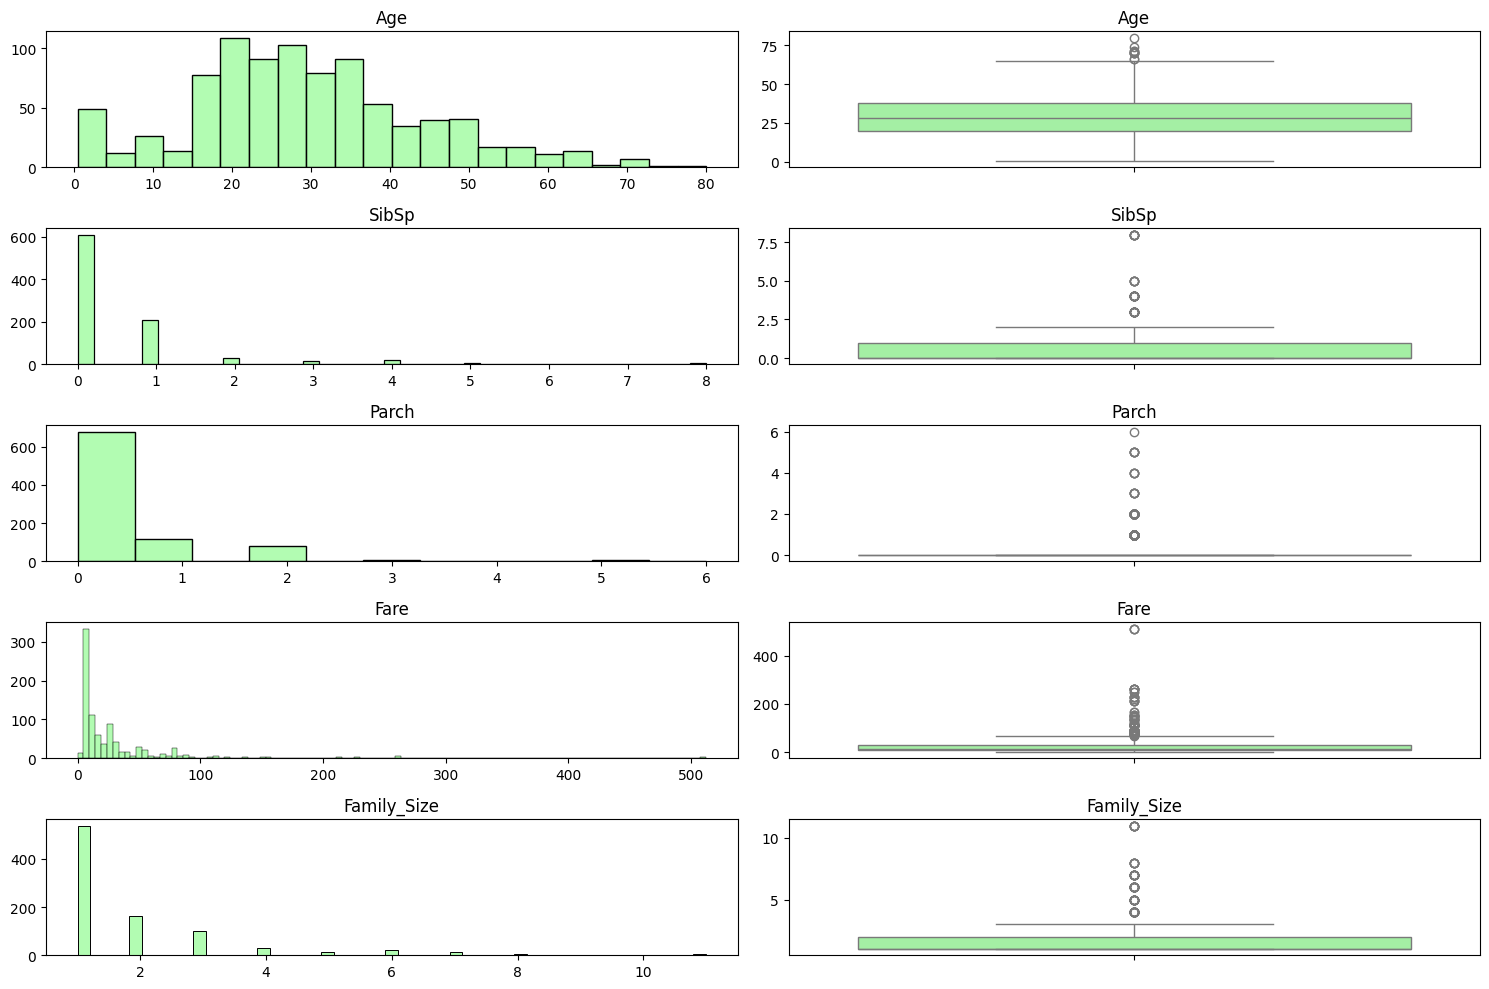

In [55]:
plot_numeric(titanic_df)

##Znajdowanie outlierow

In [75]:
def find_outlier(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    if Q1 - 1.5 * IQR < 0: # kolumny, na których sprawdzamy outliery nie powinny mieć wartości ujemnych, więc za outlier musimy uznać także wszystko > 0
      lower_bound = 0
    else:
      lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [76]:
column_names = ['Age', 'SibSp', 'Parch', 'Fare', 'Family_Size']
for name in column_names:
    outliers, lower_bound, upper_bound = find_outlier(titanic_df, name)
    print(f"{name}: {len(outliers)} outlierów, upper_bound: {upper_bound}, lower_bound{lower_bound}")

Age: 11 outlierów, upper_bound: 65.0, lower_bound0
SibSp: 46 outlierów, upper_bound: 2.5, lower_bound0
Parch: 213 outlierów, upper_bound: 0.0, lower_bound0.0
Fare: 113 outlierów, upper_bound: 66.1125, lower_bound0
Family_Size: 91 outlierów, upper_bound: 3.5, lower_bound0


##Wykresy danych kategorycznych

In [56]:
def plot_categorical_to_count(df):
  categorical_columns = ['Embarked', 'Sex', 'Pclass', 'Survived', 'Has_Cabin', "Is_Alone"]


  for idx, column in enumerate(categorical_columns, 1):
    plt.subplot(3, 2, idx)
    sns.countplot(x = df[column], color = "palegreen")
    plt.title(f"Distribution of {column}")
    plt.xlabel('')
    plt.ylabel('Count')

  plt.tight_layout()
  plt.show()

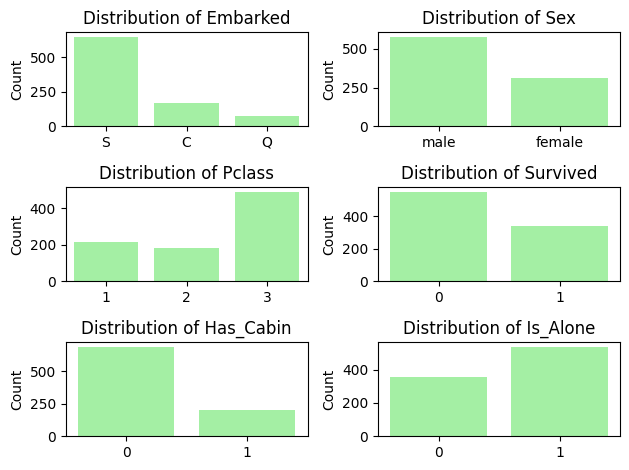

In [57]:
plot_categorical_to_count(titanic_df)

##Sprawdzamy, jak część z naszych danych ma się do przetrwania (wykresiki)

In [58]:
def column_vs_survived(df, column_name):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=column_name, hue='Survived', kde=True, palette='pastel', multiple='stack')
    plt.title(f'{column_name} vs Survived')
    plt.xlabel(column_name)
    plt.ylabel('Count')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x='Survived', y=column_name, palette='pastel')
    plt.title(f'{column_name} vs Survived')
    plt.xlabel('Survived')
    plt.ylabel(column_name)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1594/2277775020.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y=column_name, palette='pastel')


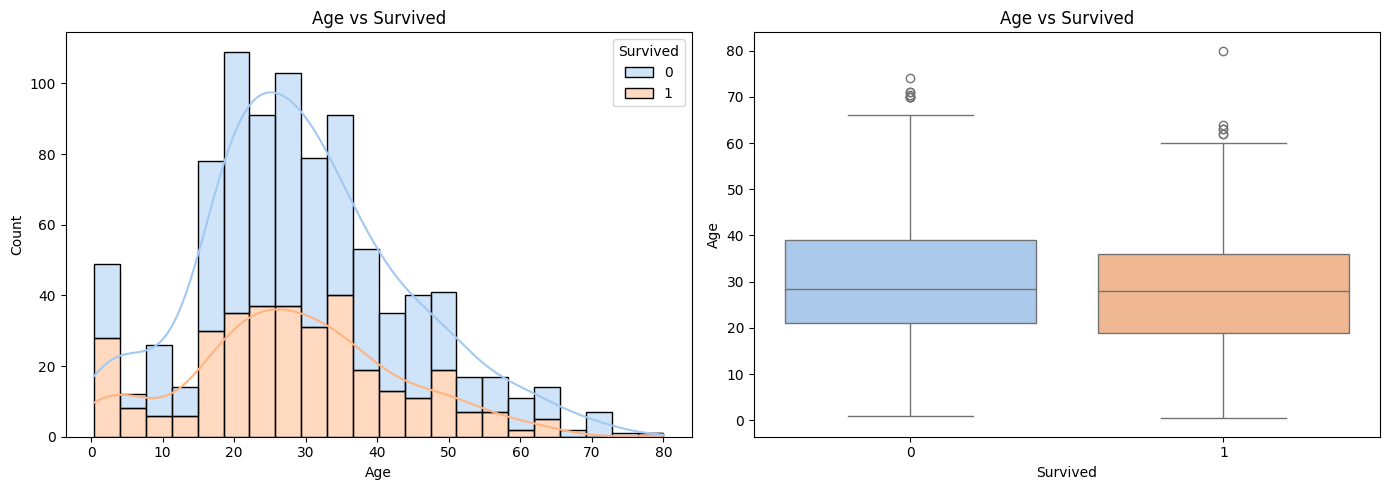

/tmp/ipykernel_1594/2277775020.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y=column_name, palette='pastel')


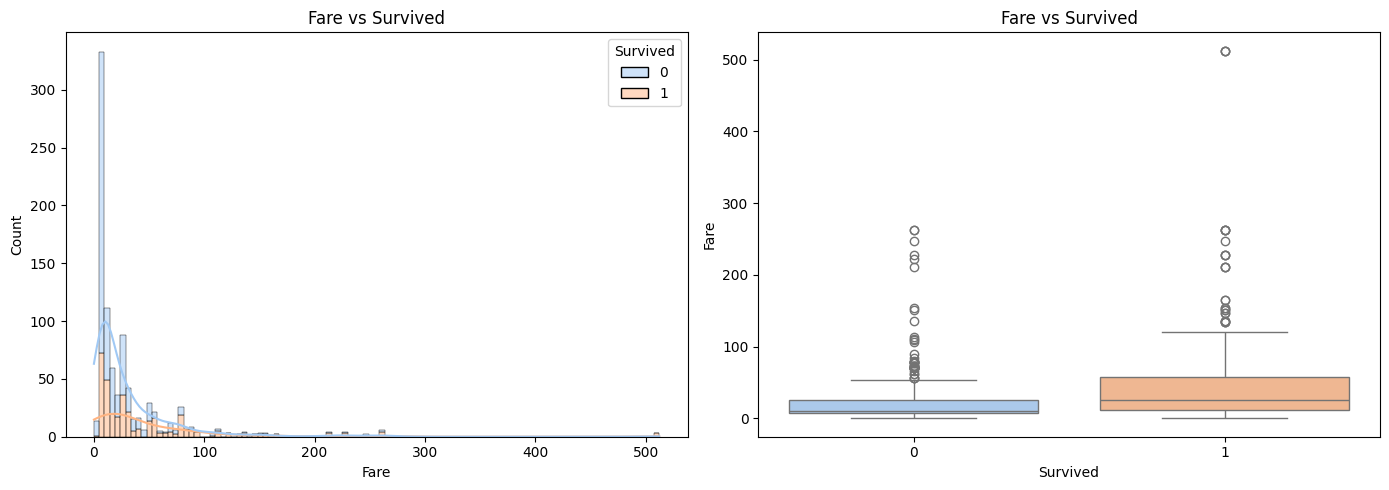

/tmp/ipykernel_1594/2277775020.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y=column_name, palette='pastel')


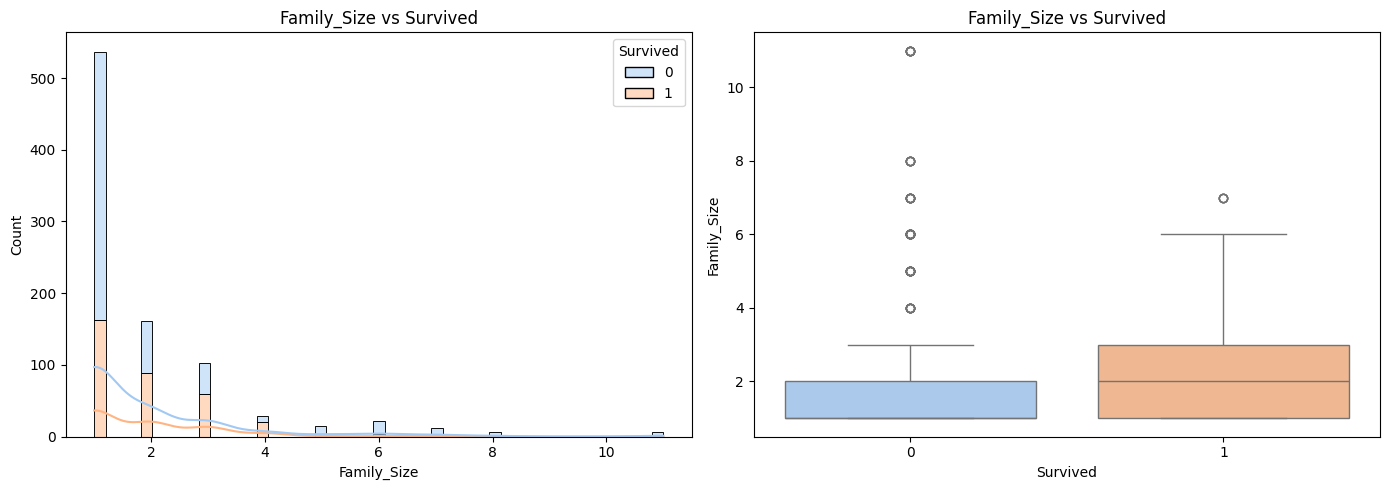

/tmp/ipykernel_1594/2277775020.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y=column_name, palette='pastel')


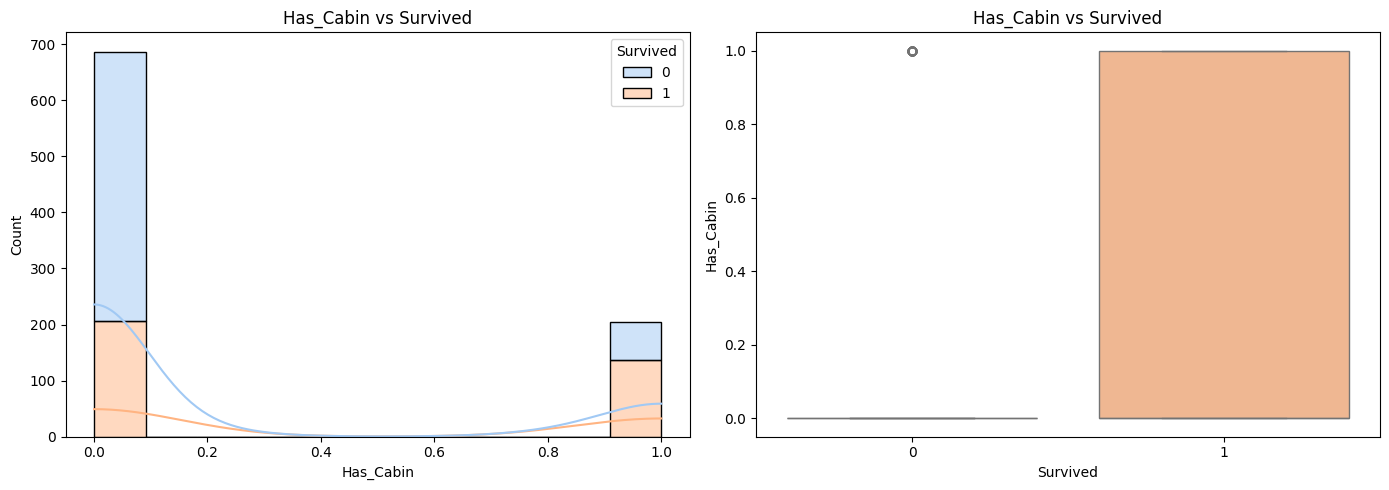

In [62]:
column_names = ['Age', 'Fare', 'Family_Size', 'Has_Cabin']
for name in column_names:
  column_vs_survived(titanic_df, name)

Sex:

Fare:

Family_Size:

Has_Cabin: tu tak jak pisałem w komentarzu przy tworzeniu Has_Cabin - dziwna zależność między posiadaniem numeru kabiny, a przetrwaniem (?)

##Zamiana danych kategorycznych na numeryczne

In [59]:
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1}) #tutaj label encoding
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True) #tutaj kodowanie gorąco jedynkowe XDD

##Macierz korelacji

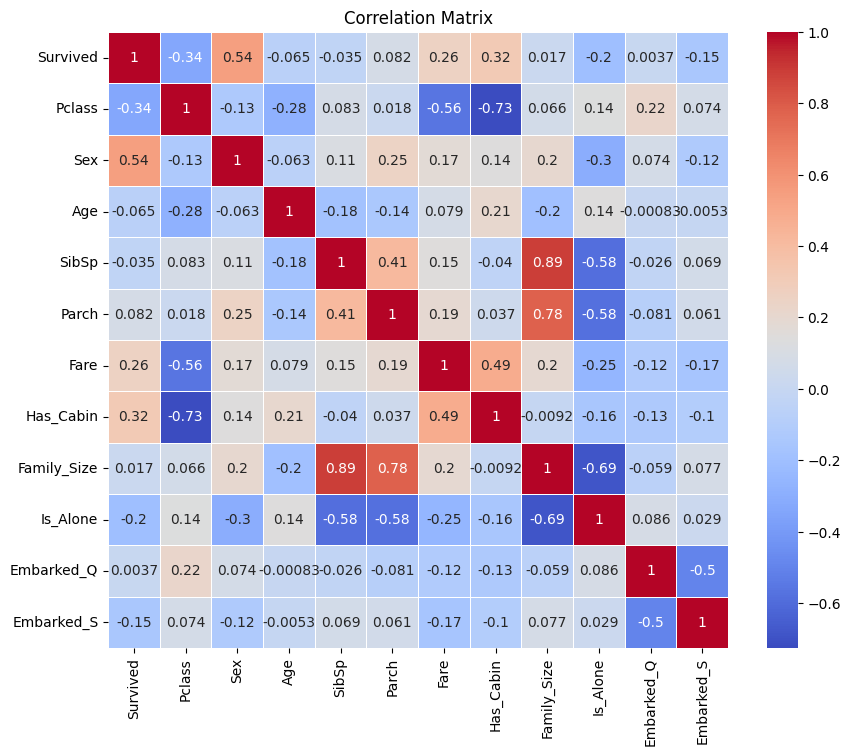

In [60]:
corr_matrix = titanic_df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Z macierzy korelacji, możemy się dowiedzieć, że Survived jest najmocniej skorelowane z płcią (Sex), co oznacza, że przeżyło więcej kobiet niż mężczyzn.

Silnie skorelowane z survived są także PClass oraz Fare, co sugeruje, że większe szanse na przeżycie miały osoby podróżujące w wyższej klasie (prawdopodobnie bogatsze)

In [64]:
titanic_df.info()
titanic_df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Has_Cabin    891 non-null    int64  
 8   Family_Size  891 non-null    int64  
 9   Is_Alone     891 non-null    int64  
 10  Embarked_Q   891 non-null    bool   
 11  Embarked_S   891 non-null    bool   
dtypes: bool(2), float64(2), int64(8)
memory usage: 71.5 KB


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin,Family_Size,Is_Alone,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,2,0,False,True
1,1,1,1,38.0,1,0,71.2833,1,2,0,False,False
2,1,3,1,26.0,0,0,7.9250,0,1,1,False,True
3,1,1,1,35.0,1,0,53.1000,1,2,0,False,True
4,0,3,0,35.0,0,0,8.0500,0,1,1,False,True
5,0,3,0,39.0,0,0,8.4583,0,1,1,True,False
6,0,1,0,54.0,0,0,51.8625,1,1,1,False,True
7,0,3,0,2.0,3,1,21.0750,0,5,0,False,True
8,1,3,1,27.0,0,2,8.0500,0,3,0,False,True
9,1,2,1,14.0,1,0,30.0708,0,2,0,False,False


Tak preznetuje się nasz ostateczny dataframe, po wykonaniu wszystkich czynności.